In [99]:
%matplotlib inline

import torch
from torch import nn
from d2l import torch as d2l

In [100]:
# 2D Optimization Helper

from collections.abc import Callable

Gradient2D = Callable[
    [float, float],
    tuple[float, float],
]

Trainer2D = Callable[
    [
        float,
        float,
        float,
        float,
        Gradient2D,
    ],
    tuple[
        float,
        float,
        float,
        float,
    ],
]

LearningRateSchedule = Callable[
    [],
    float,
]


def train_2d(
    trainer: Trainer2D,
    gradient: Gradient2D,
    num_steps: int = 50,
) -> list[tuple[float, float]]:
    
    x1 = -5.0
    x2 = -2.0
    
    # 이후 Optimization Algorithm에서 사용할 state
    state1 = 0.0
    state2 = 0.0
    
    results = [
        (x1, x2)
    ]
    
    for _ in range(num_steps):
        (
            x1,
            x2,
            state1,
            state2,
        ) = trainer(
            x1,
            x2,
            state1,
            state2,
            gradient,
        )
        
        results.append(
            (x1, x2)
        )

    print(
        f"step {num_steps}, "
        f"x1: {x1:f}, "
        f"x2: {x2:f}"
    )

    return results

In [101]:
# 2D Optimization Trace

def show_trace_2d(
    objective: Callable[
        [torch.Tensor, torch.Tensor],
        torch.Tensor,
    ],
    results: list[tuple[float, float]],
) -> None:
    points = torch.tensor(
        results,
        dtype=torch.float32,
    )

    x1_grid, x2_grid = torch.meshgrid(
        torch.arange(
            -5.5,
            1.0,
            0.1,
        ),
        torch.arange(
            -3.0,
            1.0,
            0.1,
        ),
        indexing="ij",
    )

    d2l.set_figsize()

    d2l.plt.plot(
        points[:, 0],
        points[:, 1],
        "-o",
        color="#ff7f0e",
    )

    d2l.plt.contour(
        x1_grid,
        x2_grid,
        objective(
            x1_grid,
            x2_grid,
        ),
        colors="#1f77b4",
    )

    d2l.plt.xlabel("x1")
    d2l.plt.ylabel("x2")

In [102]:
# Objective Function & Full Gradient

def objective_2d(
    x1: torch.Tensor,
    x2: torch.Tensor,
) -> torch.Tensor:
    return (
        x1.pow(2)
        + 2 * x2.pow(2)
    )
    

def objective_gradient_2d(
    x1: float,
    x2: float,
) -> tuple[float, float]:
    
    # f(x1, x2) = x1² + 2x2²
    # ∂f/∂x1 = 2x1
    # ∂f/∂x2 = 4x2
    return (
        2 * x1,
        4 * x2,
    )

In [103]:
# Constant Learning Rate

def constant_learning_rate() -> float:
    return 1.0

base_learning_rate = 0.1

learning_rate_schedule: LearningRateSchedule = (
    constant_learning_rate
)

step 50, x1: 0.024364, x2: 0.055003


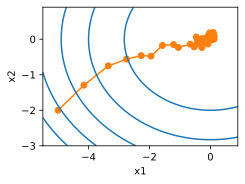

In [104]:
# Noisy Stochastic Gradient Descent

def stochastic_gradient_descent_2d(
    x1: float,
    x2: float,
    state1: float,
    state2: float,
    gradient: Gradient2D,
) -> tuple[
    float,
    float,
    float,
    float,
]:
    del state1, state2
    
    gradient1, gradient2 = gradient(
        x1,
        x2,
    )
    
    # 실제 SGD에서 example sampling으로 발생하는
    # Stochastic Gradient의 noise를 Gaussian noise로 모사
    gradient1 += torch.normal(
        mean=0.0,
        std=1.0,
        size=(),
    ).item()
    
    gradient2 += torch.normal(
        mean=0.0,
        std=1.0,
        size=(),
    ).item()
    
    current_learning_rate = (
        base_learning_rate 
        * learning_rate_schedule()
    )
    
    return (
        x1 - current_learning_rate * gradient1,
        x2 - current_learning_rate * gradient2,
        0.0,
        0.0,
    )
    
SGD_results = train_2d(
    trainer=stochastic_gradient_descent_2d,
    gradient=objective_gradient_2d,
    num_steps=50,
)

show_trace_2d(
    objective_2d,
    SGD_results,
)    

step 1000, x1: -0.816708, x2: -0.057842


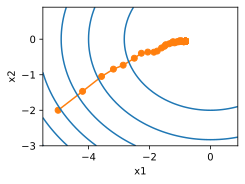

In [ ]:
# Exponential Decay

import math

schedule_step = 1

def exponential_learning_rate() -> float:
    global schedule_step

    schedule_step += 1
    
    return math.exp(
        - 0.1 * schedule_step
    )
    
learning_rate_schedule = (
    exponential_learning_rate
)

exponential_results = train_2d(
    trainer=stochastic_gradient_descent_2d,
    gradient=objective_gradient_2d,
    num_steps=1000,
)

show_trace_2d(
    objective_2d,
    exponential_results,
)

# 1000 step을 실행했지만 x1이 여전히 0에서 멀다

step 50, x1: -0.076908, x2: -0.064456


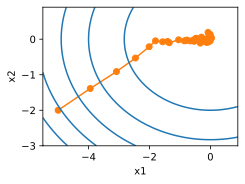

In [ ]:
# Polynomial Decay

schedule_step = 1

def polynomial_learning_rate() -> float:
    global schedule_step

    schedule_step += 1

    return (
        1
        + 0.1 * schedule_step
    ) ** (-0.5)
    

learning_rate_schedule = (
    polynomial_learning_rate
)

polynomial_results = train_2d(
    trainer=stochastic_gradient_descent_2d,
    gradient=objective_gradient_2d,
    num_steps=50,
)

show_trace_2d(
    objective_2d,
    polynomial_results,
)

# Exponential Decay보다 훨씬 적은 50 step만 실행했는데도 (0,0)에 더 가까이 접근